## **Descriptive and Probabilistic Analysis of Air Quality in Yogyakarta, Indonesia (2021)**
- **Group Number:** 12
- **Name:**
1. Muhammad Akbar Rizky Hidayat - 5027261032
2. Dhafin Abhinaya Setyawan - 5027261083
3. Jenifer Tri Fena Andhika - 5027261123
- **Topic:** Smart City

### **Background**
Air quality is one of the key indicators for assessing a city’s sustainability, especially amid the rapid growth of transportation and industrial activities across various regions of Indonesia. The “Air Quality in Yogyakarta, Indonesia (2021)” dataset contains air pollution measurement data for Yogyakarta throughout 2021. Our group chose this dataset because Yogyakarta is one of Indonesia’s major cities with high population and vehicle mobility levels, making the data relevant for providing a general picture of urban air quality. Through descriptive statistics analysis of this data, we aim to illustrate the patterns and levels of air quality in Yogyakarta throughout the year, while connecting them to the Sustainable Development Goals (SDGs), specifically SDG 3 (Good Health and Well-being), as air quality directly impacts public respiratory health, and SDG 11 (Sustainable Cities and Communities) because air quality monitoring is a crucial part of efforts to create safe, inclusive, and sustainable cities. Thus, the results of this analysis are expected to serve as a simple example of how a city’s air quality data can be used to raise awareness and data-driven decision-making toward more sustainable urban development.

### **Questions:**
1. What are the mode, median, mean, range, and variance of PM2.5 and PM10 concentrations in Yogyakarta for each month throughout the year?
2. Which hours of the day show the highest and lowest average pollutant concentrations?
3. What proportion of hours or days fall into each category (Good, Moderate, Unhealthy, Very Unhealthy, Dangerous)?

### **Data Description and Dictionary**
- Source of data: The data comes from the Yogyakarta Environmental Agency (Dinas Lingkungan Hidup Yogyakarta), which was processed and uploaded to Kaggle by Adhang MM at this link: https://www.kaggle.com/datasets/adhang/air-quality-in-yogyakarta-indonesia-2021
- License: Data files © Original Authors
- The data was collected by the Yogyakarta Environmental Agency in April 2021. Measurements were taken hourly. The original pollution values were converted into the Pollutant Standards Index (PSI/ISPU).
- The data has 11 columns for each month.
- January, March, May, July, August, October, and December consist of 744 rows.
- February consists of 674 rows.
- April, June, September, and November consist of 720 rows.

| Column | Definition | Variable Type | Scale | Units | Example |
| --- | --- | --- | --- | --- | --- |
| Date | The date measurement was taken | Qualitative | Interval | - | 4/1/2021 |
| Time | The time measurement was taken (hourly) | Qualitative | Interval | - | 00:00:00 | 
| PM2.5 | Particulate Matter 2.5 measurement (Index) | Quantitative Continuous | Ratio | PSI | 45 |
| PM10 | Particulate Matter 10 measurement (Index) | Quantitative Continuous | Ratio | PSI | 19 |
| SO2 | Sulfur Dioxide measurement (Index) | Quantitative Continuous | Ratio | PSI | 15 |
| CO | Carbon Monoxide measurement (Index) | Quantitative Continuous | Ratio | PSI | 15 |
| O3 | Ozone measurement (Index) | Quantitative Continuous | Ratio | PSI | 8 |
| NO2 | Nitrogen Dioxide measurement (Index) | Quantitative Continuous | Ratio | PSI | 3 |
| Max | Highest pollution measurement value at that hour | Quantitative Continuous | Ratio | PSI | 45 |
| Critical Component | Gas component contributing to the highest pollution | Qualitative | Nominal | - | PM2.5 |
| Category | Air quality category based on the Max value | Qualitative | Ordinal | - | Good |

### **Yogyakarta's Air Quality Dataset in January 2021**

In [227]:
import pandas as pd

df = pd.read_csv("01-jogja-jan-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,1/1/2021,00:00:00,13,40,0,25,0,0,40,PM2.5,Good
2,1/1/2021,01:00:00,12,38,0,24,0,0,38,PM2.5,Good
3,1/1/2021,02:00:00,11,35,0,23,0,0,35,PM2.5,Good
4,1/1/2021,03:00:00,10,32,0,22,0,0,32,PM2.5,Good
5,1/1/2021,04:00:00,9,29,0,21,0,0,29,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,1/31/2021,19:00:00,25,66,19,25,40,6,66,PM2.5,Moderate
741,1/31/2021,20:00:00,24,65,19,24,39,5,65,PM2.5,Moderate
742,1/31/2021,21:00:00,23,64,19,24,38,5,64,PM2.5,Moderate
743,1/31/2021,22:00:00,23,63,19,24,38,5,63,PM2.5,Moderate


#### <span style="color:blue">**Data Quality Check**</span>

In [228]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 01-jogja-jan-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Date                744 non-null    str  
 1   Time                744 non-null    str  
 2   PM10                744 non-null    int64
 3   PM2.5               744 non-null    int64
 4   SO2                 744 non-null    int64
 5   CO                  744 non-null    int64
 6   O3                  744 non-null    int64
 7   NO2                 744 non-null    int64
 8   Max                 744 non-null    int64
 9   Critical Component  744 non-null    str  
 10  Category            744 non-null    str  
dtypes: int64(7), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [229]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 01-jogja-jan-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000
mean,16.063172,46.782258,14.005376,24.534946,22.290323,2.469086,48.432796
std,8.358234,18.616724,10.531244,3.355775,17.578254,2.179462,16.666334
min,2.000000,12.000000,0.000000,17.000000,0.000000,0.000000,19.000000
25%,8.000000,30.000000,1.000000,22.000000,0.000000,0.000000,34.000000
50%,16.000000,52.000000,20.000000,25.000000,26.000000,3.000000,52.000000
75%,21.000000,60.000000,23.000000,27.000000,38.000000,4.000000,60.000000
max,35.000000,80.000000,28.000000,33.000000,55.000000,7.000000,80.000000


##### <span style="color:blue">**1. PM2.5**</span>

In [230]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: 01-jogja-jan-2021.csv
Mean: 46.78225806451613
Median: 52.0
Mode: 55
Variance: 346.58240350801026
Standard Deviation: 18.616723758707124
Q1 (25%): 30.0
Q3 (75%): 60.0


##### <span style="color:blue">**2. PM10**</span>

In [231]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM10"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: 01-jogja-jan-2021.csv
Mean: 16.063172043010752
Median: 16.0
Mode: 6
Variance: 69.8600685248701
Standard Deviation: 8.358233576831298
Q1 (25%): 8.0
Q3 (75%): 21.0


##### <span style="color:blue">**3. CO**</span>

In [232]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["CO"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: 01-jogja-jan-2021.csv
Mean: 24.53494623655914
Median: 25.0
Mode: 26
Variance: 11.261226645827003
Standard Deviation: 3.3557751184826143
Q1 (25%): 22.0
Q3 (75%): 27.0


##### <span style="color:blue">**4. O3**</span>

In [233]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["O3"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: 01-jogja-jan-2021.csv
Mean: 22.29032258064516
Median: 26.0
Mode: 0
Variance: 308.9950071636348
Standard Deviation: 17.57825381440474
Q1 (25%): 0.0
Q3 (75%): 38.0


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [234]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 01-jogja-jan-2021.csv


Critical Component
PM2.5    82.930108
O3       11.424731
CO        4.704301
SO2       0.940860
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [235]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 01-jogja-jan-2021.csv


Category
Moderate    53.897849
Good        46.102151
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 01-jogja-jan-2021.csv


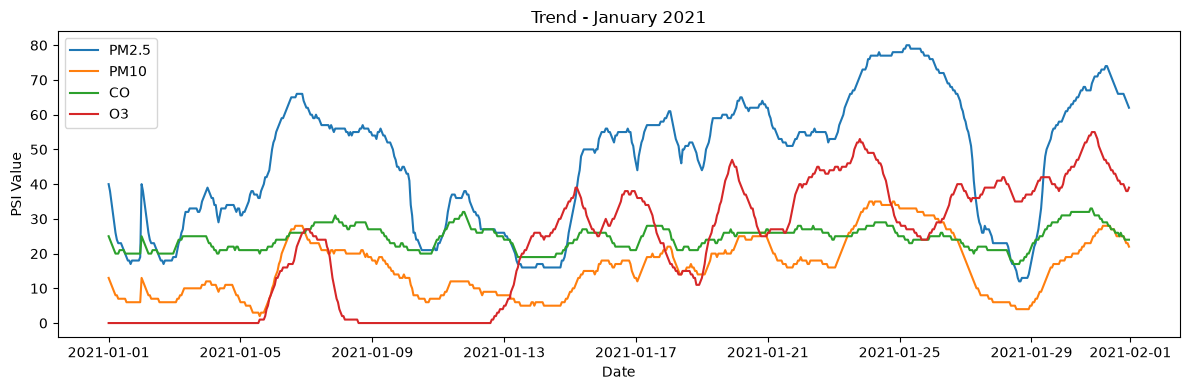

In [236]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the January data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - January 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 01-jogja-jan-2021.csv


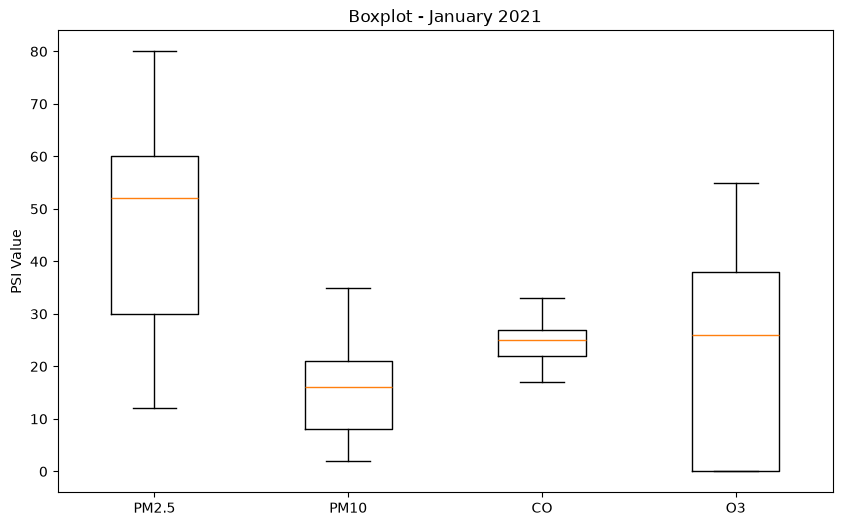

In [237]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - January 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 01-jogja-jan-2021.csv


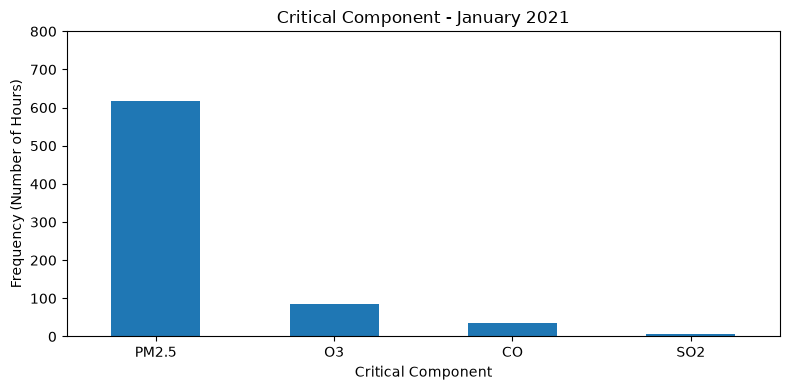

Critical Component
PM2.5    617
O3        85
CO        35
SO2        7
Name: count, dtype: int64

In [238]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df_jan["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - January 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: 01-jogja-jan-2021.csv


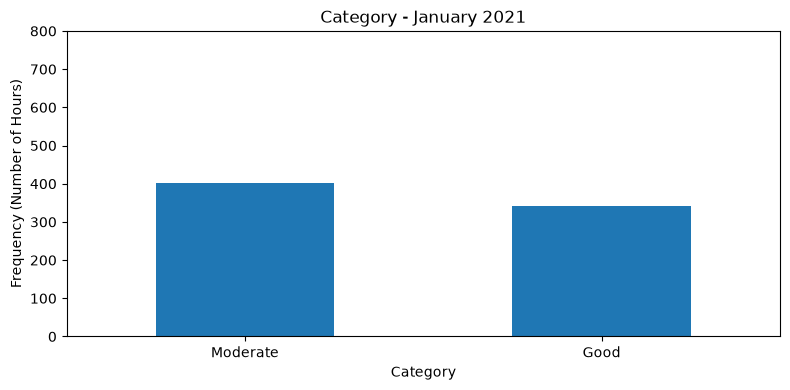

Category
Moderate    401
Good        343
Name: count, dtype: int64

In [239]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df_jan["Category"].value_counts().plot(kind="bar")
plt.title("Category - January 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in February 2021**

In [240]:
import pandas as pd

df = pd.read_csv("02-jogja-feb-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(672)

(672, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,2/1/2021,00:00:00,21,61,18,23,38.0,5,61,PM2.5,Moderate
2,2/1/2021,01:00:00,20,60,18,23,38.0,5,60,PM2.5,Moderate
3,2/1/2021,02:00:00,20,59,18,23,39.0,5,59,PM2.5,Moderate
4,2/1/2021,03:00:00,20,59,18,24,39.0,5,59,PM2.5,Moderate
5,2/1/2021,04:00:00,20,60,18,24,39.0,5,60,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
668,2/28/2021,19:00:00,9,34,17,10,33.0,6,34,PM2.5,Good
669,2/28/2021,20:00:00,9,35,17,11,33.0,6,35,PM2.5,Good
670,2/28/2021,21:00:00,10,37,18,12,34.0,6,37,PM2.5,Good
671,2/28/2021,22:00:00,11,40,18,13,34.0,6,40,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [241]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 02-jogja-feb-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                672 non-null    str    
 1   Time                672 non-null    str    
 2   PM10                672 non-null    int64  
 3   PM2.5               672 non-null    int64  
 4   SO2                 672 non-null    int64  
 5   CO                  672 non-null    int64  
 6   O3                  657 non-null    float64
 7   NO2                 672 non-null    int64  
 8   Max                 672 non-null    int64  
 9   Critical Component  672 non-null    str    
 10  Category            672 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 57.9 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [242]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 02-jogja-feb-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,672.000000,672.000000,672.000000,672.000000,657.000000,672.000000,672.000000
mean,18.760417,57.680060,20.964286,23.467262,34.925419,4.153274,58.943452
std,5.818725,11.901872,2.458945,5.749785,14.579750,1.379655,10.728450
min,7.000000,26.000000,16.000000,7.000000,9.000000,2.000000,27.000000
25%,15.000000,52.000000,19.000000,23.000000,24.000000,3.000000,53.000000
50%,19.000000,59.000000,20.000000,24.000000,35.000000,4.000000,60.000000
75%,24.000000,66.000000,22.000000,26.000000,41.000000,5.000000,67.000000
max,30.000000,80.000000,31.000000,38.000000,71.000000,8.000000,80.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [255]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 02-jogja-feb-2021.csv


Critical Component
PM2.5    87.053571
O3       12.946429
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [256]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 02-jogja-feb-2021.csv


Category
Moderate    82.738095
Good        17.261905
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 02-jogja-feb-2021.csv


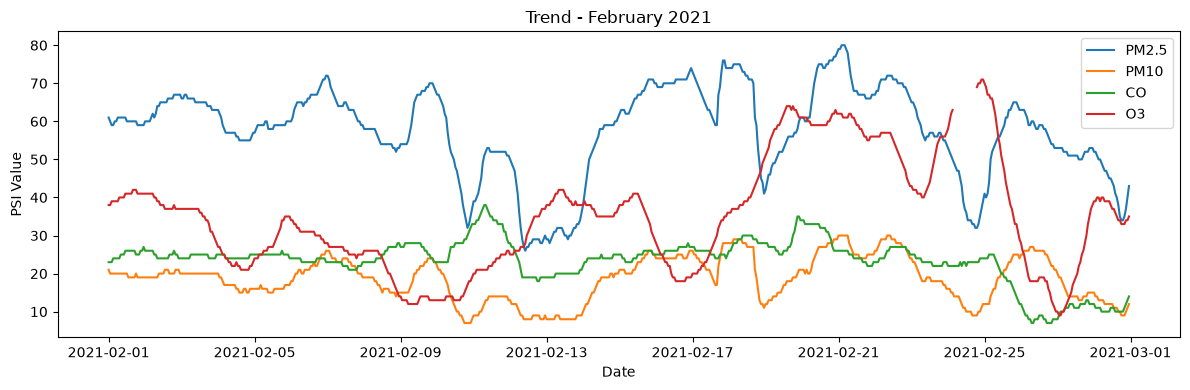

In [257]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the February data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - February 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 02-jogja-feb-2021.csv


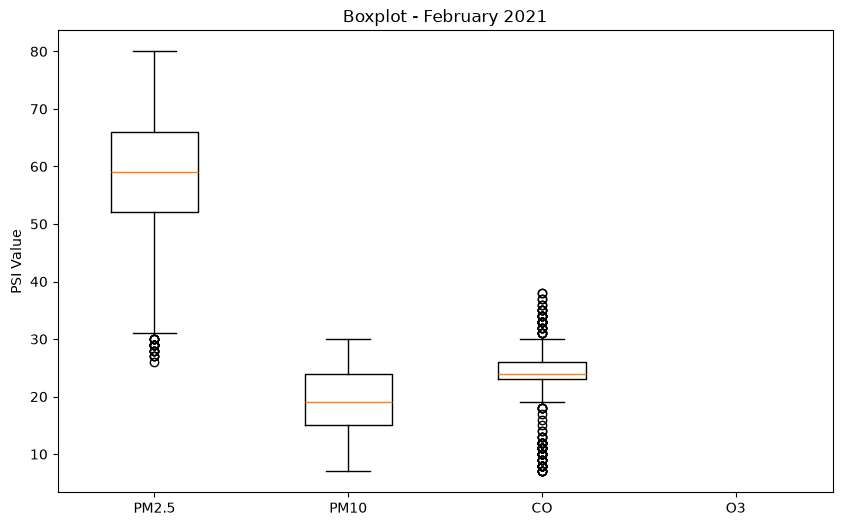

In [258]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - February 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 02-jogja-feb-2021.csv


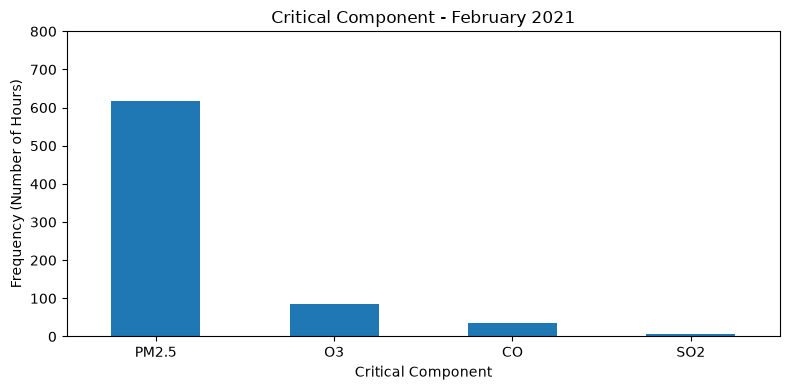

Critical Component
PM2.5    585
O3        87
Name: count, dtype: int64

In [260]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df_jan["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - February 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: 02-jogja-feb-2021.csv


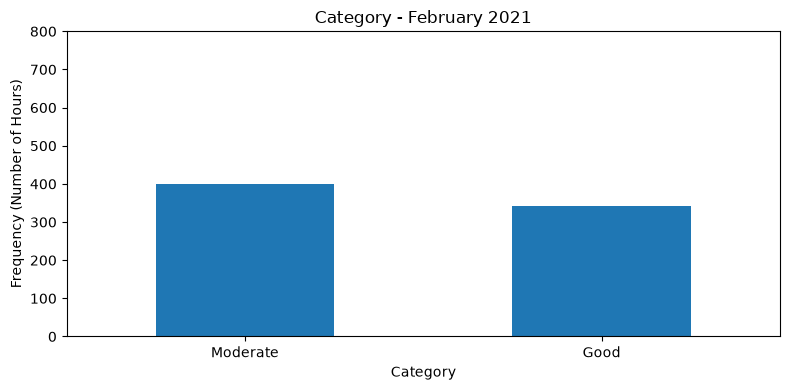

Category
Moderate    556
Good        116
Name: count, dtype: int64

In [261]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df_jan["Category"].value_counts().plot(kind="bar")
plt.title("Category - February 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in March 2021**

In [243]:
import pandas as pd

df = pd.read_csv("03-jogja-mar-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,3/1/2021,00:00:00,13,48,19,15,35,6,48,PM2.5,Good
2,3/1/2021,01:00:00,14,51,19,16,36,6,51,PM2.5,Moderate
3,3/1/2021,02:00:00,15,52,20,17,37,6,52,PM2.5,Moderate
4,3/1/2021,03:00:00,16,54,20,17,37,6,54,PM2.5,Moderate
5,3/1/2021,04:00:00,17,55,21,18,38,6,55,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
740,3/31/2021,19:00:00,21,50,22,17,8,3,50,PM2.5,Good
741,3/31/2021,20:00:00,21,50,21,16,8,3,50,PM2.5,Good
742,3/31/2021,21:00:00,20,49,21,16,8,3,49,PM2.5,Good
743,3/31/2021,22:00:00,20,48,21,16,8,3,48,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [262]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 03-jogja-mar-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Date                744 non-null    str  
 1   Time                744 non-null    str  
 2   PM10                744 non-null    int64
 3   PM2.5               744 non-null    int64
 4   SO2                 744 non-null    int64
 5   CO                  744 non-null    int64
 6   O3                  744 non-null    int64
 7   NO2                 744 non-null    int64
 8   Max                 744 non-null    int64
 9   Critical Component  744 non-null    str  
 10  Category            744 non-null    str  
dtypes: int64(7), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [264]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 03-jogja-mar-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000
mean,17.873656,44.424731,19.880376,12.037634,4.922043,3.793011,44.424731
std,6.276290,13.350931,2.623620,4.460828,7.092873,1.257079,13.350931
min,7.000000,19.000000,14.000000,4.000000,0.000000,2.000000,19.000000
25%,13.000000,35.000000,18.000000,8.000000,1.000000,3.000000,35.000000
50%,17.000000,42.000000,19.000000,11.000000,2.000000,3.000000,42.000000
75%,21.000000,53.000000,22.000000,15.000000,7.000000,4.000000,53.000000
max,41.000000,92.000000,27.000000,24.000000,38.000000,7.000000,92.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [265]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 03-jogja-mar-2021.csv


Critical Component
PM2.5    100.0
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [267]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 03-jogja-mar-2021.csv


Category
Good        67.607527
Moderate    32.392473
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 03-jogja-mar-2021.csv


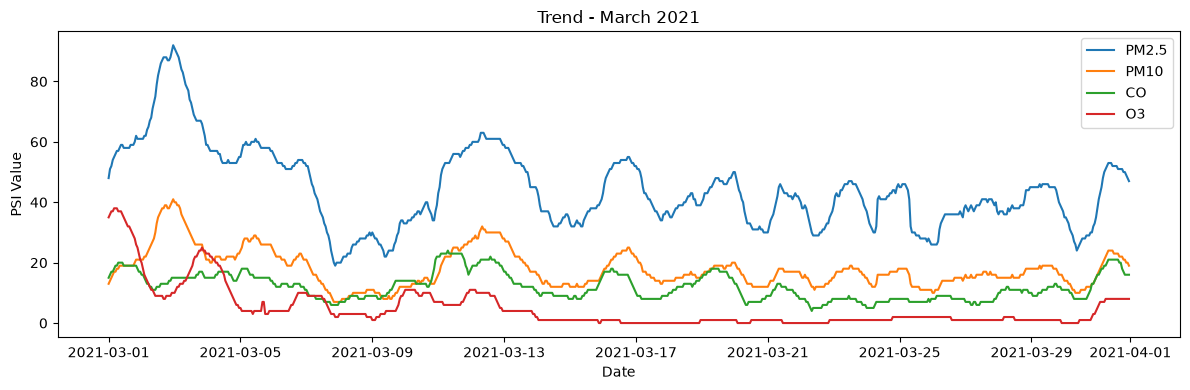

In [278]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the March data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - March 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 03-jogja-mar-2021.csv


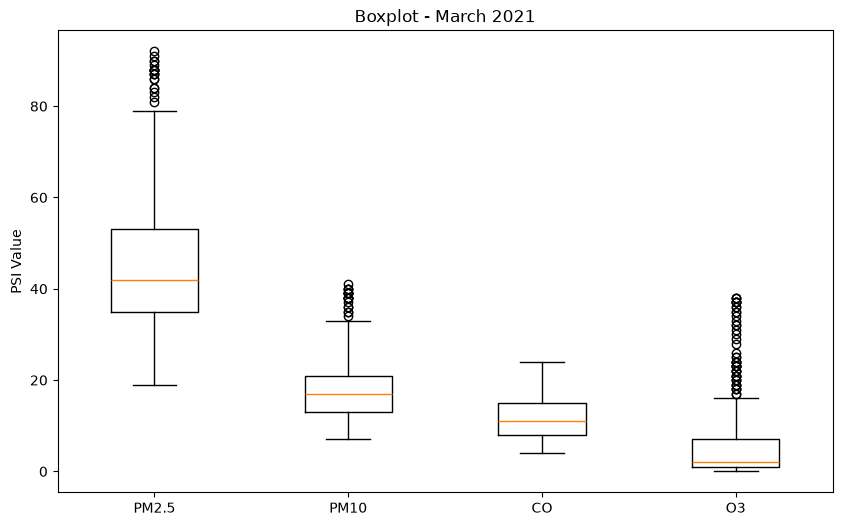

In [270]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - March 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 03-jogja-mar-2021.csv


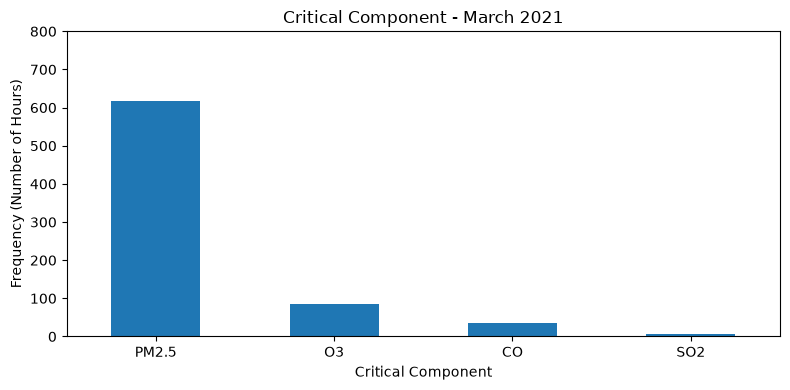

Critical Component
PM2.5    744
Name: count, dtype: int64

In [271]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df_jan["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - March 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: 03-jogja-mar-2021.csv


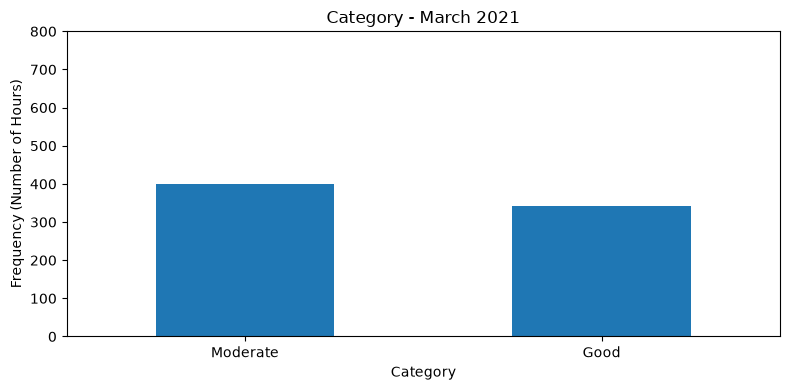

Category
Good        503
Moderate    241
Name: count, dtype: int64

In [272]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df_jan["Category"].value_counts().plot(kind="bar")
plt.title("Category - March 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in April 2021**

In [244]:
import pandas as pd

df = pd.read_csv("04-jogja-apr-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM2.5,PM10,SO2,CO,O3,NO2,Max,Critical Component,Category
1,4/1/2021,00:00:00,45,19,21,15,8.0,3,21,PM2.5,Good
2,4/1/2021,01:00:00,44,18,20,14,8.0,3,20,PM2.5,Good
3,4/1/2021,02:00:00,43,17,20,14,7.0,3,20,PM2.5,Good
4,4/1/2021,03:00:00,40,17,20,13,7.0,3,20,PM2.5,Good
5,4/1/2021,04:00:00,38,16,19,12,7.0,3,19,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
716,4/30/2021,19:00:00,54,23,17,14,NaN,4,23,PM2.5,Good
717,4/30/2021,20:00:00,54,23,17,14,NaN,4,23,PM2.5,Good
718,4/30/2021,21:00:00,54,23,17,13,NaN,4,23,PM2.5,Good
719,4/30/2021,22:00:00,54,23,17,13,NaN,4,23,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [273]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 04-jogja-apr-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    str    
 1   Time                720 non-null    str    
 2   PM2.5               720 non-null    int64  
 3   PM10                720 non-null    int64  
 4   SO2                 720 non-null    int64  
 5   CO                  720 non-null    int64  
 6   O3                  621 non-null    float64
 7   NO2                 720 non-null    int64  
 8   Max                 720 non-null    int64  
 9   Critical Component  720 non-null    str    
 10  Category            720 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 62.0 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [274]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 04-jogja-apr-2021.csv


,PM2.5,PM10,SO2,CO,O3,NO2,Max
count,720.000000,720.000000,720.000000,720.000000,621.000000,720.000000,720.000000
mean,44.290278,18.830556,16.641667,11.547222,23.774557,3.848611,25.137500
std,10.556183,6.091482,3.306661,4.215409,9.962708,1.487312,8.569716
min,19.000000,8.000000,11.000000,5.000000,7.000000,2.000000,14.000000
25%,35.000000,14.000000,14.000000,9.000000,18.000000,3.000000,20.000000
50%,45.000000,18.000000,16.000000,11.000000,21.000000,3.000000,23.000000
75%,53.000000,23.000000,19.000000,13.000000,27.000000,5.000000,27.000000
max,66.000000,36.000000,28.000000,24.000000,65.000000,8.000000,65.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [275]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 04-jogja-apr-2021.csv


Critical Component
PM2.5    91.666667
O3        8.333333
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [276]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 04-jogja-apr-2021.csv


Category
Good        97.5
Moderate     2.5
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 04-jogja-apr-2021.csv


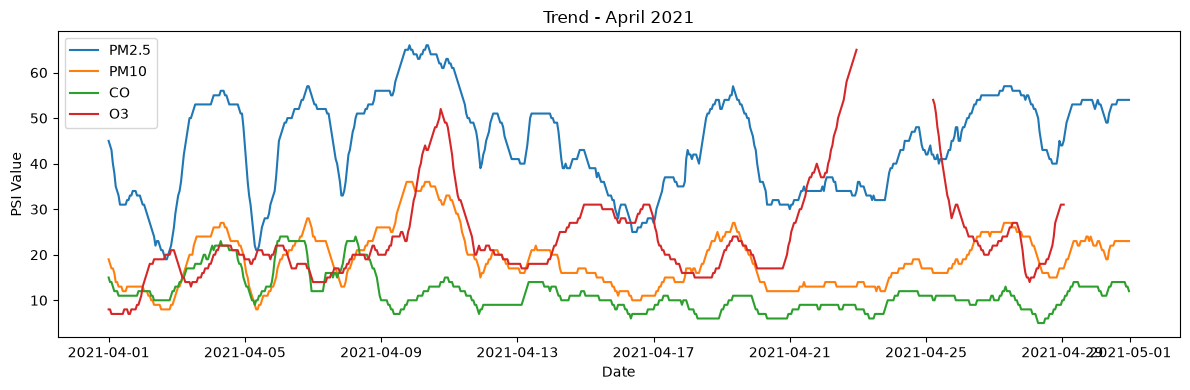

In [277]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the April data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - April 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 04-jogja-apr-2021.csv


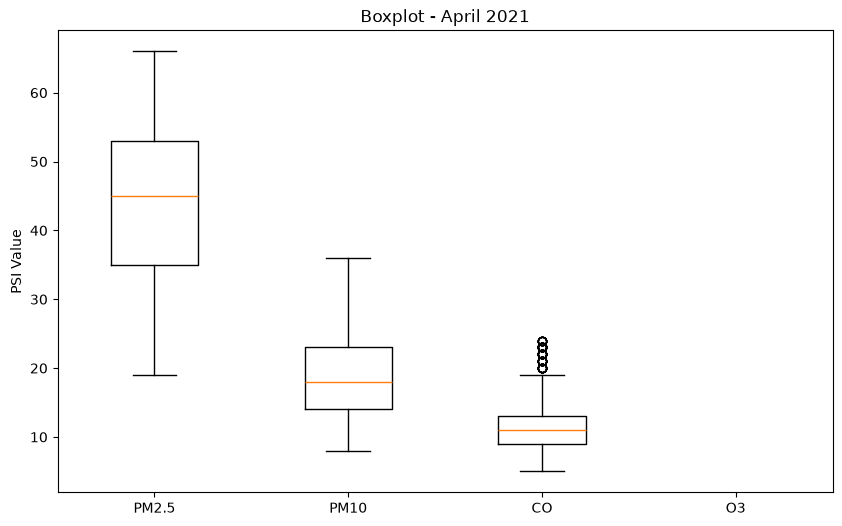

In [279]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - April 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 04-jogja-apr-2021.csv


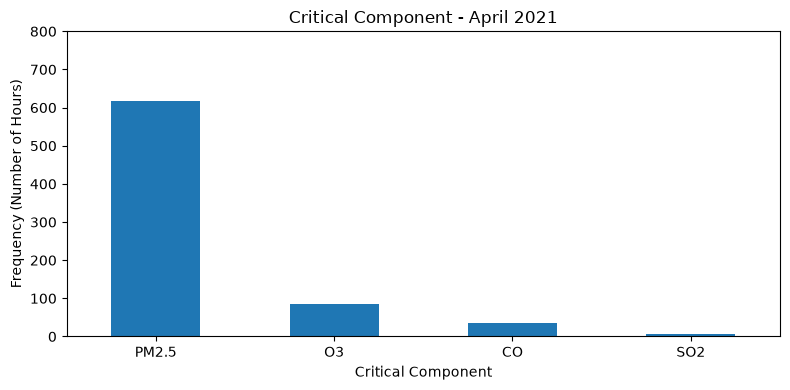

Critical Component
PM2.5    660
O3        60
Name: count, dtype: int64

In [280]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df_jan["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - April 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: 04-jogja-apr-2021.csv


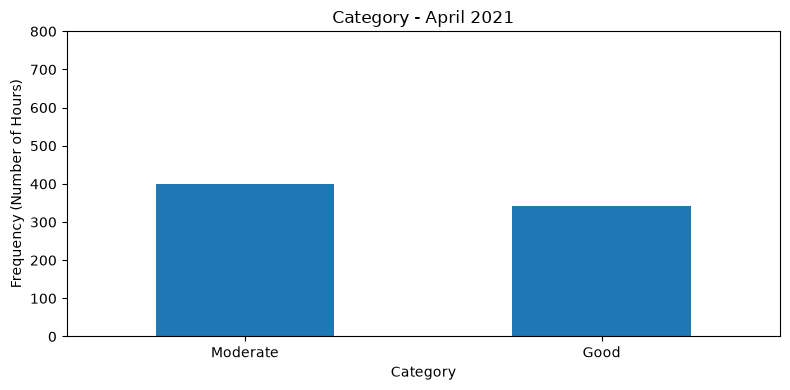

Category
Good        702
Moderate     18
Name: count, dtype: int64

In [281]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df_jan["Category"].value_counts().plot(kind="bar")
plt.title("Category - April 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in May 2021**

In [245]:
import pandas as pd

df = pd.read_csv("05-jogja-may-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,5/1/2021,00:00:00,22,53,17,12,NaN,4,53,PM2.5,Moderate
2,5/1/2021,01:00:00,22,52,17,12,NaN,4,52,PM2.5,Moderate
3,5/1/2021,02:00:00,21,52,17,12,NaN,4,52,PM2.5,Moderate
4,5/1/2021,03:00:00,22,52,17,12,NaN,4,52,PM2.5,Moderate
5,5/1/2021,04:00:00,22,53,17,12,NaN,4,53,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
740,5/31/2021,19:00:00,21,50,19,9,21.0,6,50,PM2.5,Good
741,5/31/2021,20:00:00,21,50,20,9,19.0,6,50,PM2.5,Good
742,5/31/2021,21:00:00,20,50,20,9,17.0,5,50,PM2.5,Good
743,5/31/2021,22:00:00,20,49,20,8,15.0,5,49,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [282]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 05-jogja-may-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                744 non-null    str    
 1   Time                744 non-null    str    
 2   PM10                744 non-null    int64  
 3   PM2.5               744 non-null    int64  
 4   SO2                 744 non-null    int64  
 5   CO                  744 non-null    int64  
 6   O3                  498 non-null    float64
 7   NO2                 744 non-null    int64  
 8   Max                 744 non-null    int64  
 9   Critical Component  744 non-null    str    
 10  Category            744 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [283]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 05-jogja-may-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,744.000000,744.000000,744.000000,744.000000,498.000000,744.000000,744.000000
mean,24.138441,54.159946,17.251344,8.466398,35.524096,5.043011,54.422043
std,5.780733,5.873494,2.978613,2.949818,12.889736,1.125158,5.956265
min,13.000000,36.000000,11.000000,3.000000,10.000000,3.000000,36.000000
25%,20.000000,51.000000,15.000000,6.000000,24.000000,4.000000,51.000000
50%,22.000000,53.000000,18.000000,8.000000,37.000000,5.000000,54.000000
75%,28.000000,58.000000,20.000000,10.000000,46.000000,6.000000,59.000000
max,41.000000,69.000000,24.000000,18.000000,63.000000,8.000000,69.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [284]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 05-jogja-may-2021.csv


Critical Component
PM2.5    95.430108
O3        4.569892
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [286]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 05-jogja-may-2021.csv


Category
Moderate    77.956989
Good        22.043011
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 05-jogja-may-2021.csv


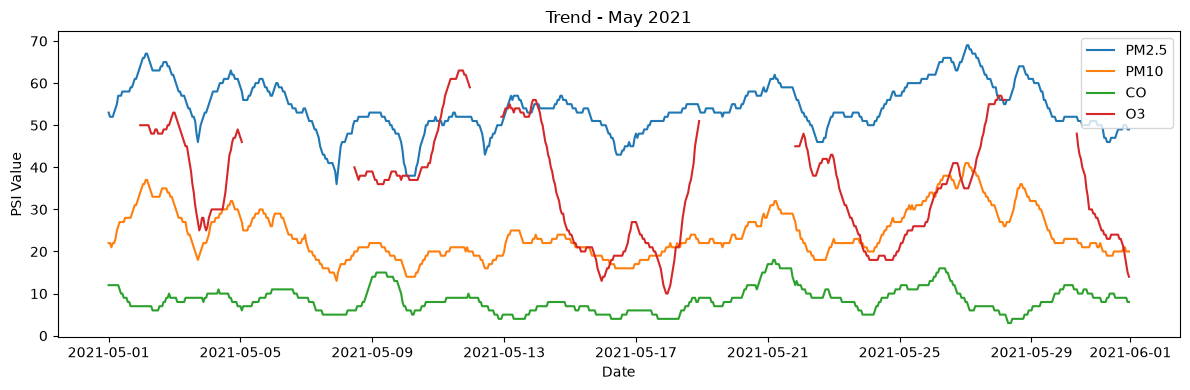

In [288]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the May data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - May 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 05-jogja-may-2021.csv


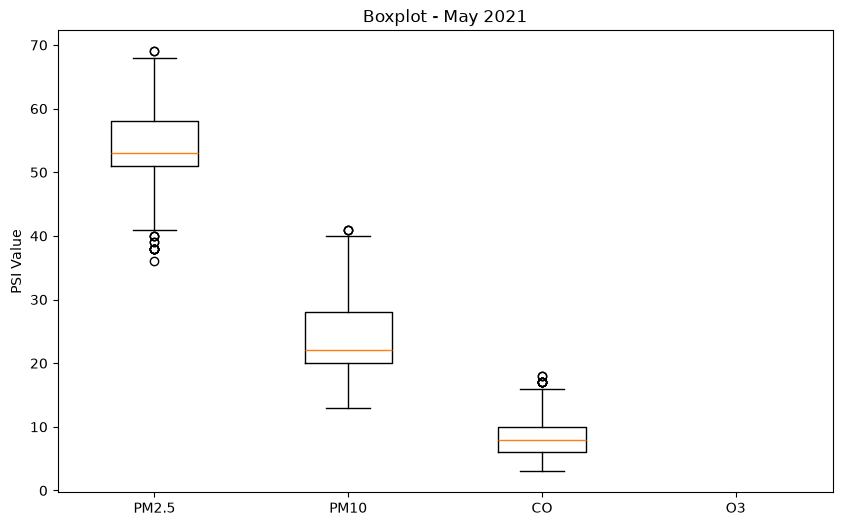

In [290]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - May 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 05-jogja-may-2021.csv


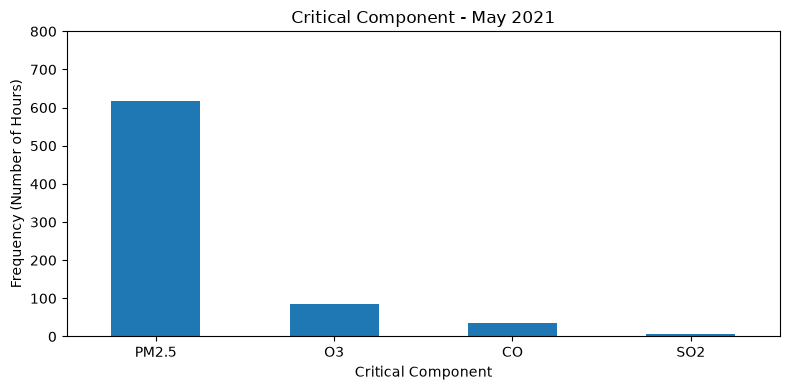

Critical Component
PM2.5    710
O3        34
Name: count, dtype: int64

In [291]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df_jan["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - May 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: 05-jogja-may-2021.csv


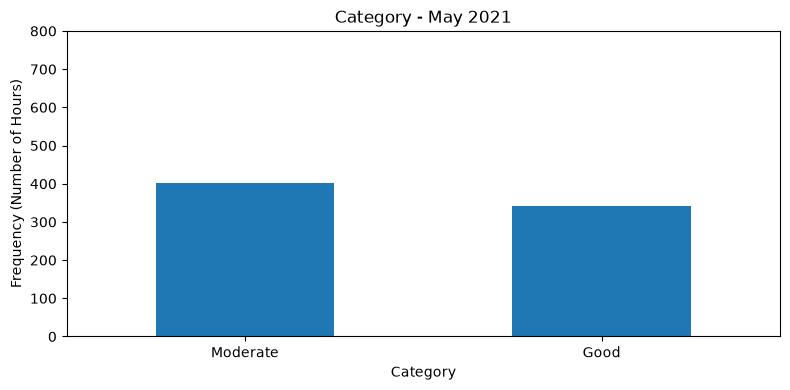

Category
Moderate    580
Good        164
Name: count, dtype: int64

In [292]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df_jan["Category"].value_counts().plot(kind="bar")
plt.title("Category - May 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in June 2021**

In [246]:
import pandas as pd

df = pd.read_csv("06-jogja-jun-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,6/1/2021,00:00:00,20,48,21.0,8,14.0,5,48,PM2.5,Good
2,6/1/2021,01:00:00,20,49,21.0,8,14.0,5,49,PM2.5,Good
3,6/1/2021,02:00:00,21,50,21.0,8,14.0,5,50,PM2.5,Good
4,6/1/2021,03:00:00,21,51,21.0,9,15.0,5,51,PM2.5,Moderate
5,6/1/2021,04:00:00,22,51,22.0,9,16.0,5,51,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
716,6/30/2021,19:00:00,41,62,NaN,13,NaN,6,62,PM2.5,Moderate
717,6/30/2021,20:00:00,40,62,NaN,12,NaN,6,62,PM2.5,Moderate
718,6/30/2021,21:00:00,39,61,NaN,12,NaN,6,61,PM2.5,Moderate
719,6/30/2021,22:00:00,38,60,NaN,11,NaN,6,60,PM2.5,Moderate


#### <span style="color:blue">**Data Quality Check**</span>

In [293]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 06-jogja-jun-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    str    
 1   Time                720 non-null    str    
 2   PM10                720 non-null    int64  
 3   PM2.5               720 non-null    int64  
 4   SO2                 118 non-null    float64
 5   CO                  720 non-null    int64  
 6   O3                  74 non-null     float64
 7   NO2                 720 non-null    int64  
 8   Max                 720 non-null    int64  
 9   Critical Component  720 non-null    str    
 10  Category            720 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 62.0 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [294]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 06-jogja-jun-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,720.000000,720.000000,118.000000,720.000000,74.000000,720.000000,720.000000
mean,24.056944,50.343056,32.618644,10.869444,26.864865,6.159722,50.343056
std,11.447690,11.595540,20.116719,4.104973,10.432200,1.530693,11.595540
min,0.000000,17.000000,14.000000,3.000000,14.000000,3.000000,17.000000
25%,18.000000,42.000000,16.000000,7.000000,20.000000,5.000000,42.000000
50%,24.000000,51.000000,21.000000,11.000000,22.000000,6.000000,51.000000
75%,29.000000,56.000000,58.750000,13.000000,34.000000,7.000000,56.000000
max,52.000000,77.000000,64.000000,22.000000,49.000000,10.000000,77.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [295]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 06-jogja-jun-2021.csv


Critical Component
PM2.5    100.0
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [296]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 06-jogja-jun-2021.csv


Category
Moderate    55.972222
Good        44.027778
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 06-jogja-jun-2021.csv


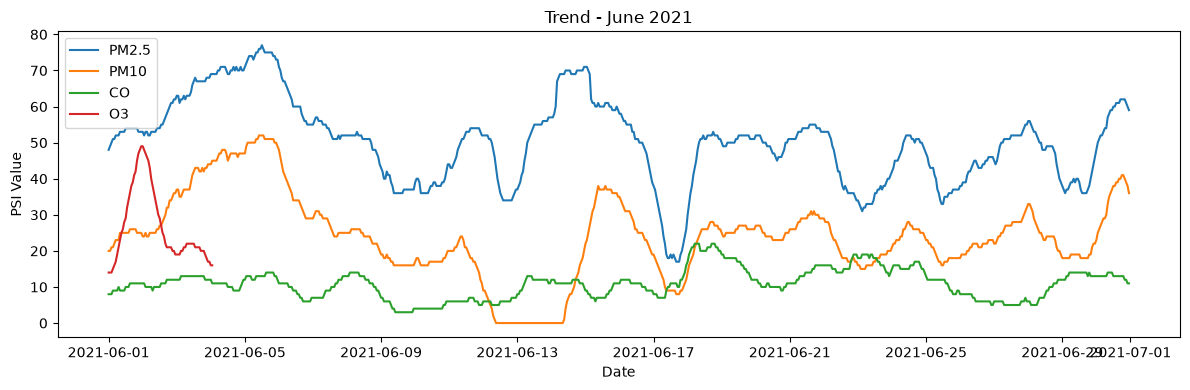

In [297]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the June data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - June 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 06-jogja-jun-2021.csv


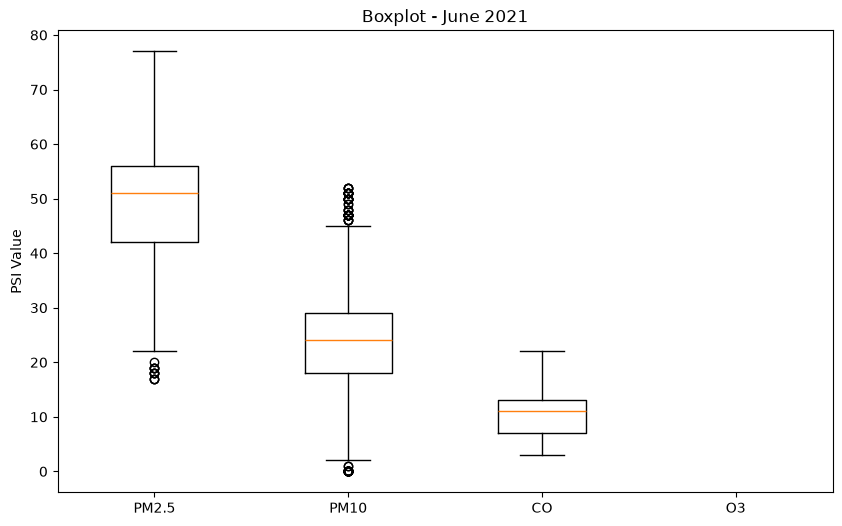

In [298]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - June 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 06-jogja-jun-2021.csv


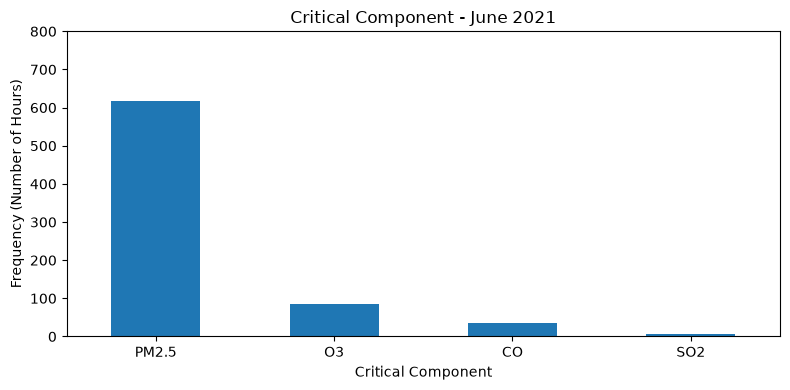

Critical Component
PM2.5    720
Name: count, dtype: int64

In [299]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df_jan["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - June 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: 06-jogja-jun-2021.csv


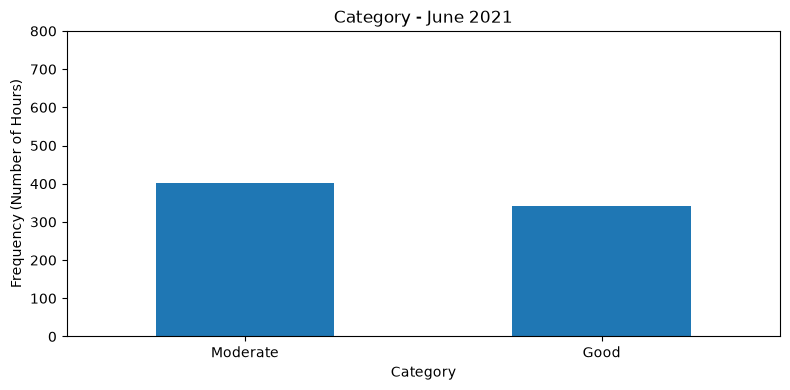

Category
Moderate    403
Good        317
Name: count, dtype: int64

In [300]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df_jan["Category"].value_counts().plot(kind="bar")
plt.title("Category - June 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in July 2021**

In [247]:
import pandas as pd

df = pd.read_csv("07-jogja-jul-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,7/1/2021,00:00:00,35.0,58.0,NaN,11.0,NaN,5.0,58,PM2.5,Moderate
2,7/1/2021,01:00:00,34.0,57.0,NaN,10.0,NaN,5.0,57,PM2.5,Moderate
3,7/1/2021,02:00:00,33.0,57.0,NaN,10.0,NaN,5.0,57,PM2.5,Moderate
4,7/1/2021,03:00:00,32.0,56.0,NaN,10.0,NaN,5.0,56,PM2.5,Moderate
5,7/1/2021,04:00:00,31.0,55.0,NaN,9.0,NaN,5.0,55,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
740,7/31/2021,19:00:00,11.0,25.0,NaN,1.0,NaN,2.0,25,PM2.5,Good
741,7/31/2021,20:00:00,11.0,24.0,NaN,1.0,NaN,2.0,24,PM2.5,Good
742,7/31/2021,21:00:00,11.0,24.0,NaN,1.0,NaN,2.0,24,PM2.5,Good
743,7/31/2021,22:00:00,10.0,24.0,NaN,1.0,NaN,2.0,24,PM2.5,Good


### **Yogyakarta's Air Quality Dataset in August 2021**

In [248]:
import pandas as pd

df = pd.read_csv("08-jogja-aug-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,8/1/2021,00:00:00,10.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
2,8/1/2021,01:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
3,8/1/2021,02:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
4,8/1/2021,03:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
5,8/1/2021,04:00:00,11.0,24.0,NaN,1.0,NaN,3.0,24,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,8/31/2021,19:00:00,16.0,31.0,NaN,9.0,NaN,3.0,31,PM2.5,Good
741,8/31/2021,20:00:00,16.0,31.0,NaN,9.0,NaN,3.0,31,PM2.5,Good
742,8/31/2021,21:00:00,16.0,31.0,NaN,9.0,NaN,3.0,31,PM2.5,Good
743,8/31/2021,22:00:00,16.0,32.0,NaN,9.0,NaN,3.0,32,PM2.5,Good


### **Yogyakarta's Air Quality Dataset in September 2021**

In [249]:
import pandas as pd

df = pd.read_csv("09-jogja-sep-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,9/1/2021,00:00:00,16.0,28.0,0.0,7.0,0.0,4.0,28,PM2.5,Good
2,9/1/2021,01:00:00,16.0,28.0,0.0,7.0,0.0,4.0,28,PM2.5,Good
3,9/1/2021,02:00:00,16.0,28.0,0.0,7.0,0.0,4.0,28,PM2.5,Good
4,9/1/2021,03:00:00,18.0,32.0,0.0,7.0,1.0,4.0,32,PM2.5,Good
5,9/1/2021,04:00:00,18.0,32.0,0.0,6.0,1.0,4.0,32,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
716,9/30/2021,19:00:00,19.0,35.0,0.0,7.0,4.0,4.0,35,PM2.5,Good
717,9/30/2021,20:00:00,19.0,35.0,0.0,7.0,4.0,4.0,35,PM2.5,Good
718,9/30/2021,21:00:00,19.0,36.0,0.0,7.0,5.0,4.0,36,PM2.5,Good
719,9/30/2021,22:00:00,20.0,36.0,0.0,7.0,5.0,4.0,36,PM2.5,Good


### **Yogyakarta's Air Quality Dataset in October 2021**

In [250]:
import pandas as pd

df = pd.read_csv("10-jogja-oct-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,10/1/2021,00:00:00,19.0,35.0,0.0,7.0,5.0,4.0,35,PM2.5,Good
2,10/1/2021,01:00:00,19.0,35.0,0.0,7.0,5.0,4.0,35,PM2.5,Good
3,10/1/2021,02:00:00,18.0,34.0,0.0,7.0,6.0,4.0,34,PM2.5,Good
4,10/1/2021,03:00:00,16.0,30.0,0.0,7.0,7.0,4.0,30,PM2.5,Good
5,10/1/2021,04:00:00,16.0,30.0,0.0,7.0,8.0,4.0,30,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,10/31/2021,19:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
741,10/31/2021,20:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
742,10/31/2021,21:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
743,10/31/2021,22:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good


### **Yogyakarta's Air Quality Dataset in November 2021**

In [251]:
import pandas as pd

df = pd.read_csv("11-jogja-nov-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,11/1/2021,00:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
2,11/1/2021,01:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
3,11/1/2021,02:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
4,11/1/2021,03:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
5,11/1/2021,04:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
716,11/30/2021,19:00:00,45.0,53.0,27.0,20.0,33.0,0.0,53,PM2.5,Moderate
717,11/30/2021,20:00:00,45.0,53.0,27.0,20.0,33.0,0.0,53,PM2.5,Moderate
718,11/30/2021,21:00:00,43.0,51.0,26.0,20.0,34.0,0.0,51,PM2.5,Moderate
719,11/30/2021,22:00:00,37.0,47.0,26.0,19.0,35.0,0.0,47,PM2.5,Good


### **Yogyakarta's Air Quality Dataset in December 2021**

In [252]:
import pandas as pd

df = pd.read_csv("12-jogja-dec-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,12/1/2021,00:00:00,26.0,38.0,25.0,19.0,36.0,0.0,38,PM2.5,Good
2,12/1/2021,01:00:00,24.0,36.0,24.0,18.0,37.0,0.0,37,O3,Good
3,12/1/2021,02:00:00,23.0,34.0,23.0,18.0,38.0,0.0,38,O3,Good
4,12/1/2021,03:00:00,18.0,31.0,23.0,17.0,39.0,0.0,39,O3,Good
5,12/1/2021,04:00:00,17.0,31.0,22.0,17.0,40.0,0.0,40,O3,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,12/31/2021,19:00:00,15.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good
741,12/31/2021,20:00:00,16.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good
742,12/31/2021,21:00:00,17.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good
743,12/31/2021,22:00:00,18.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good


### **Conclusion**
jjj